Ising model simulation for L = 50

In [1]:
import numpy as np
import random 
import matplotlib.pyplot as plt
import math
from scipy.optimize import curve_fit

PARAMETERS

In [13]:
J = 1.0  # Interaction strength
k_B = 1.0
Tc = 2 / (math.log(1 + math.sqrt(2)))  # Critical temperature
L_big = 75 
L_small =25

FUNCTIONS

In [31]:
def calc_energy(lattice, xi, xj, L, J):
    spin = lattice[xi, xj]
    n_neighbours = (lattice[(xi+1)%L, xj] + lattice[(xi-1)%L, xj] +lattice[xi, (xj+1)%L] + lattice[xi, (xj-1)%L])
    return 2 * J * spin * n_neighbours


# MAIN FUNCTION THAT SIMULATES ISING MODEL
def Ising(lattice, T, L, time):
    M = []  # Magnetization
    E = []  # Energy
    e_tot = 0
    nn = L**2 
    
    # Calculate initial total energy
    for i in range(L):
        for j in range(L):
            spin = lattice[i, j]
            n_neighbours = lattice[(i+1)%L, j] + lattice[i, (j+1)%L]
            e_tot -= J * spin * n_neighbours
    
    for t in range(time):
        for _ in range(nn):  
            xi = np.random.randint(0, L)
            xj = np.random.randint(0, L)
            dE = calc_energy(lattice, xi, xj, L, J)
            
            if dE < 0 or np.random.random() < np.exp(-dE / (k_B * T)):
                lattice[xi, xj] = -lattice[xi, xj]
                e_tot += dE
        
        # store magnetization and energy per spin
        M.append(np.sum(lattice) / nn)
        E.append(e_tot / nn)
    
    return lattice, M, E



# FUNCTION TO CALCULATE AVERAGES
def Averages(T, L, magnetiz_eq, energy_eq):
    s_m = 0
    s_e = 0
    ss_m = 0
    ss_e = 0
    N = L**2
# Average magnetization per spin 
    for i in range(len(magnetiz_eq)):  
        x = magnetiz_eq[i]
        s_m += x
        ss_m += x**2
        y = energy_eq[i]
        s_e += y
        ss_e += y**2
# Average of magnetization
    mean_magnetiz = s_m / len(magnetiz_eq)
    sigma_magnetiz = math.sqrt((ss_m / len(magnetiz_eq) - (s_m / len(magnetiz_eq))**2) / len(magnetiz_eq))

# Magnetic susceptibility
    magnetic_suscept = (1/(k_B*T))*N*(ss_m / len(magnetiz_eq) - (s_m / len(magnetiz_eq))**2)

# AVerage of energy    
    mean_en = s_e / len(energy_eq)
    sigma_en = math.sqrt((ss_e / len(energy_eq)  - (s_e / len(energy_eq))**2) / len(energy_eq) )
# specific heat
    specific_heat = (ss_e / len(energy_eq) - (s_e / len(energy_eq))**2)/(k_B*T**2)    
    return mean_magnetiz, sigma_magnetiz, magnetic_suscept, mean_en, sigma_en, specific_heat



def Fluctuations(T, L, magnetiz_eq, energy_eq, camp): # camp is the number of samples 
    n = int(len(magnetiz_eq) / camp)
    susciptibilities = np.zeros(camp) # array of mean observables of blocks. number of blocks = camp 
    specific_heats = np.zeros(camp)
    
    N = L**2
# Average magnetization per spin 
    for j in range(camp): 
        s_m = 0
        s_e = 0
        ss_m = 0
        ss_e = 0
        for i in range(n):  
            x = magnetiz_eq[j*n + i]
            s_m += x
            ss_m += x**2
            y = energy_eq[j*n+ i]
            s_e += y
            ss_e += y**2
        
        magnetic_suscept = (1 / (k_B * T)) * N * (ss_m / n - (s_m / n)**2)
        specific_heat = (ss_e / n - (s_e / n)**2) / (k_B * T**2)

        susciptibilities[j] = magnetic_suscept
        specific_heats[j] = specific_heat
    
    sigma_chi = np.std(susciptibilities) / np.sqrt(camp)
    sigma_C = np.std(specific_heats) / np.sqrt(camp) 
    final_chi = np.mean(susciptibilities)
    final_C = np.mean(specific_heats)

    return final_chi, final_C, sigma_chi, sigma_C





# FUNCTION TO CALCULTE CORRELATION FUNCTIONS
def corr_function(O):
    t_max = len(O)
    C_t = []
    max_t = int(t_max * 0.15)
    
    for t in range(max_t):
        sum1 = 0
        sum2 = 0
        sum3 = 0
        count = t_max - t
        
        for t_prime in range(count):
            sum1 += O[t_prime] * O[t_prime + t]
            sum2 += O[t_prime]
            sum3 += O[t_prime + t]
        
        C_t.append((sum1 / count) - (sum2 / count) * (sum3 / count))
    
    return C_t


# LONGER CORRELATION
def corr_function_long(O):
    t_max = len(O)
    C_t = []
    max_t = int(t_max * 0.4)
    
    for t in range(max_t):
        sum1 = 0
        sum2 = 0
        sum3 = 0
        count = t_max - t
        
        for t_prime in range(count):
            sum1 += O[t_prime] * O[t_prime + t]
            sum2 += O[t_prime]
            sum3 += O[t_prime + t]
        
        C_t.append((sum1 / count) - (sum2 / count) * (sum3 / count))
    
    return C_t    


# NEW ERROR BARS WITH CORRELATION TIME 
def NewErrors(tcorr_m, tcorr_e, magnetization, energy, L):
    sum_m = 0
    sum_e = 0
    ssum_m = 0
    ssum_e = 0
    N = L**2

    # NEW ERROR BARS 
    for i in range(len(magnetization)):  
        x = magnetization[i]
        sum_m += x
        ssum_m += x**2
    
        y = energy[i]
        sum_e += y
        ssum_e += y**2
# for the magnetization
    sigma_magnetiz_new = math.sqrt((1 + 2*tcorr_m/1)*(ssum_m / len(magnetization) - (sum_m / len(magnetization))**2) / len(magnetization))
    print('new error bars for the magnetization  ', sigma_magnetiz_new)

# for the energy
    sigma_energy_new = math.sqrt((1 + 2*tcorr_e/1)*(ssum_e / len(energy)  - (sum_e / len(energy))**2) / len(energy))
    print('new error bars for the energy  ', sigma_energy_new)
    


In [4]:
# function to save my data
def save_data(lattice, M, E, lattice_file, M_file, E_file):
    np.save(lattice_file, lattice)
    np.save(M_file, M)
    np.save(E_file, E)
    print(f"Dati salvati:\n- {lattice_file}\n- {M_file}\n- {E_file}")

def load_data(l_file, m_file, e_file):
    lattice = np.load(l_file)
    m = np.load(m_file)
    e = np.load(e_file)
    print(f"Dati caricati:\n- {l_file}\n- {m_file}\n- {e_file}")
    return lattice, m, e 

# L= 50

---------------------------------------------------------------------------------$T = 0.8T_c$------------------------------------------------------------------------------------------

In [71]:
L = 50 
time = 2000  # Monte Carlo steps

In [72]:
# initial configuration of the lattice
lattice = np.random.choice([-1,1], size=(L,L)) 
lattice, magnetization, energy = Ising(lattice, 0.8*Tc, L, time)

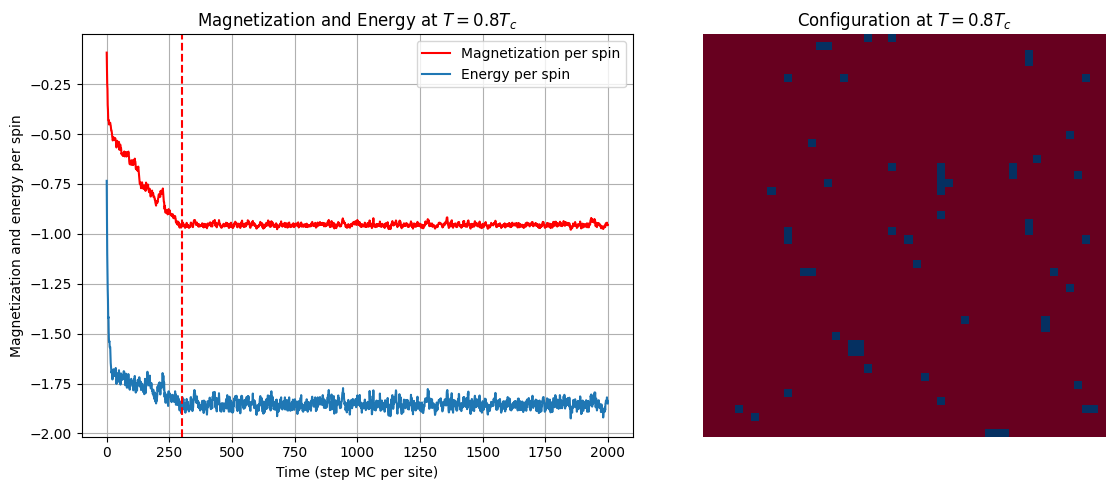

In [74]:

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].plot(magnetization, color='r',label = 'Magnetization per spin' )
ax[0].plot(energy, label = 'Energy per spin')
ax[0].set_title("Magnetization and Energy at $T = 0.8 T_c$")
ax[0].set_xlabel("Time (step MC per site)")
ax[0].set_ylabel("Magnetization and energy per spin")
ax[0].grid(True)
ax[0].axvline(x=300, color='red', linestyle='--')
ax[0].legend()

ax[1].imshow(lattice, cmap='RdBu')
ax[1].set_title("Configuration at $T = 0.8 T_c$")
ax[1].axis('off')
plt.tight_layout()
plt.show()


--- Averages ---

In [75]:
#calcoloaverages
t_eq = 300
magnetiz_eq = magnetization[t_eq:]
energy_eq = energy[t_eq:]
print(len(magnetization))
print(len(energy))
print(len(magnetiz_eq))
print(len(energy_eq))
print(magnetiz_eq)

2000
2000
1700
1700
[np.float64(-0.9488), np.float64(-0.9464), np.float64(-0.9408), np.float64(-0.9464), np.float64(-0.9488), np.float64(-0.9488), np.float64(-0.948), np.float64(-0.9584), np.float64(-0.9608), np.float64(-0.9568), np.float64(-0.9624), np.float64(-0.9624), np.float64(-0.9688), np.float64(-0.9584), np.float64(-0.968), np.float64(-0.9648), np.float64(-0.9632), np.float64(-0.9552), np.float64(-0.964), np.float64(-0.9448), np.float64(-0.956), np.float64(-0.9544), np.float64(-0.9632), np.float64(-0.9576), np.float64(-0.956), np.float64(-0.9632), np.float64(-0.9584), np.float64(-0.9624), np.float64(-0.9704), np.float64(-0.9648), np.float64(-0.9616), np.float64(-0.9656), np.float64(-0.9664), np.float64(-0.9608), np.float64(-0.9552), np.float64(-0.9472), np.float64(-0.9432), np.float64(-0.9512), np.float64(-0.9512), np.float64(-0.948), np.float64(-0.9528), np.float64(-0.9576), np.float64(-0.964), np.float64(-0.9632), np.float64(-0.9664), np.float64(-0.96), np.float64(-0.9472), n

In [84]:
M, sigma_M, chi_M, E, sigma_E, C_V = Averages(0.8*Tc, L, magnetiz_eq, energy_eq) 
print('Average of the magnetization  ' f"{M} \u00B1 {sigma_M}")
print('Average of the energy  ' f"{E} \u00B1 {sigma_E}")
print('Magnetic susceptibility  ', chi_M)
print('Specific heat   ', C_V)
fin_chi50, fin_C50, sigma_chi50, sigma_C50 = Fluctuations(0.8*Tc, L, magnetiz_eq, energy_eq, 34)
print('Final susceptiblity (blocks)  ' f"{fin_chi50}1 \u00B1 {sigma_chi50}")
print('Final specific heat (blocks)  ' f"{fin_C50} \u00B1 {sigma_C50}")

Average of the magnetization  -0.9548494117647052 ± 0.00021757901115049348
Average of the energy  -1.8538635294117654 ± 0.0005612860229718557
Magnetic susceptibility   0.11083144005252303
Specific heat    0.00016251650507787238
Final susceptiblity (blocks)  0.102744674232938481 ± 0.00825979445719152
Final specific heat (blocks)  0.00015427136117510465 ± 7.943377852097484e-06


--- --- Correlation time estimation --- --- 

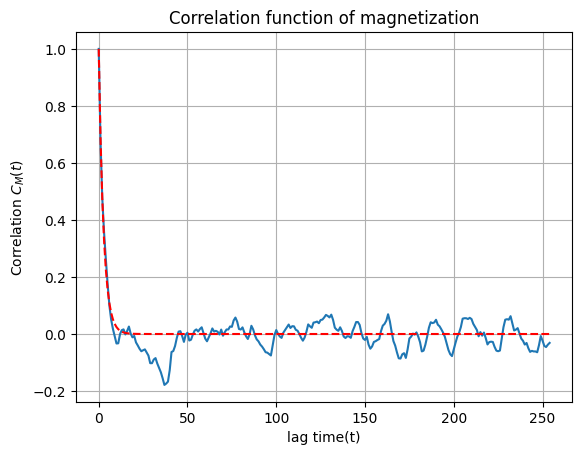

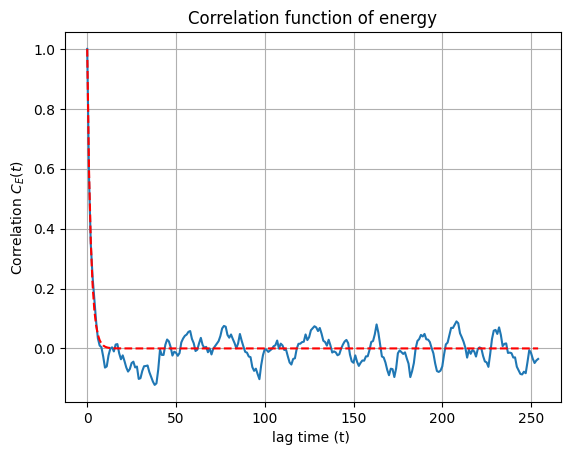

fit correlation time for energy  1.9482815043044832
fit correlation time for magnetization   2.6955736125947425


In [76]:
# Calculation
C_M = corr_function(magnetiz_eq)
C_E = corr_function(energy_eq)

C_m_norm = np.array([x / C_M[0] for x in C_M])
C_e_norm = np.array([y / C_E[0] for y in C_E])
# Grafico della funzione di correlazione

def exp_decay(t, a):
    return np.exp(-t / a)

t = np.arange(len(C_e_norm))

fit_set_e = (t >= 0) & (t <= 20)    # Energy correlation function fit
x_fit_e = t[fit_set_e]
C_e_fit = C_e_norm[fit_set_e]
popt, pcov = curve_fit(exp_decay, x_fit_e, C_e_fit)  
a_fit_e = popt[0]  
exp_E = exp_decay(t, a_fit_e)

fit_set_m = (t >= 0) & (t <= 40)    # Magnetization correlation function fit
x_fit_m = t[fit_set_m]
C_m_fit = C_m_norm[fit_set_m]
popt, pcov = curve_fit(exp_decay, x_fit_m, C_m_fit)  
a_fit_m = popt[0]  
exp_M = exp_decay(t, a_fit_m)

plt.plot(C_m_norm)
plt.plot(t, exp_M, color='red', linestyle='--')
plt.xlabel("lag time(t)")
#plt.xlim(-2, 100)
plt.ylabel("Correlation $C_M(t)$")
plt.title("Correlation function of magnetization")
plt.grid()
plt.show()


plt.plot(C_e_norm)
plt.plot(t, exp_E, color='red', linestyle='--')
#plt.xlim(-2, 75)
plt.xlabel("lag time (t) ")
plt.ylabel("Correlation $C_E(t)$")
plt.title("Correlation function of energy")
plt.grid()
plt.show()

print('fit correlation time for energy ', a_fit_e)
print('fit correlation time for magnetization  ', a_fit_m )


In [77]:
# Estimation correlation time
s = 0
for i in range(len(C_m_norm)): 
    s += C_m_norm[i]

print('estimation 2nd method correlation time for the magnetization ', s)


l = 0
for i in range(len(C_e_norm)):
    l += C_e_norm[i]

print('estimation 2nd method correlation time for the energy ', l)

estimation 2nd method correlation time for the magnetization  0.5986336423404016
estimation 2nd method correlation time for the energy  0.19562683089930805


In [78]:
# New errors estimated for energy and magnetization. in this case the correlation time tau > delta_t, not exactly tau >> delta_t
tcorr_m = 3 # Estimate of correlation time for the magnetization 
tcorr_e = 2 # Estimate of correlation time  for the energy

sum_m = 0
sum_e = 0
ssum_m = 0
ssum_e = 0
N = L**2

# NEW ERROR BARS 
for i in range(len(magnetiz_eq)):  
    x = magnetiz_eq[i]
    sum_m += x
    ssum_m += x**2
    
    y = energy_eq[i]
    sum_e += y
    ssum_e += y**2
# for the magnetization
sigma_magnetiz_new = math.sqrt((1 + 2*tcorr_m/1)*(ssum_m / len(magnetiz_eq) - (sum_m / len(magnetiz_eq))**2) / len(magnetiz_eq))
print('new error bars for the magnetization  ', sigma_magnetiz_new)

# for the energy
sigma_energy_new = math.sqrt((1 + 2*tcorr_e/1)*(ssum_e / len(energy_eq)  - (sum_e / len(energy_eq))**2) / len(energy_eq))
print('new error bars for the energy  ', sigma_energy_new)



new error bars for the magnetization   0.0005756599540115554
new error bars for the energy   0.001255073702185578


--------------------------------------------------------------------$T = 1.05Tc$--------------------------------------------------------------------------

In [79]:
L = 50
time = 6000
lattice2 = np.random.choice([-1,1], size=(L,L)) 
lattice2, magnetization2, energy2 = Ising(lattice2, 1.05*Tc, L, time)

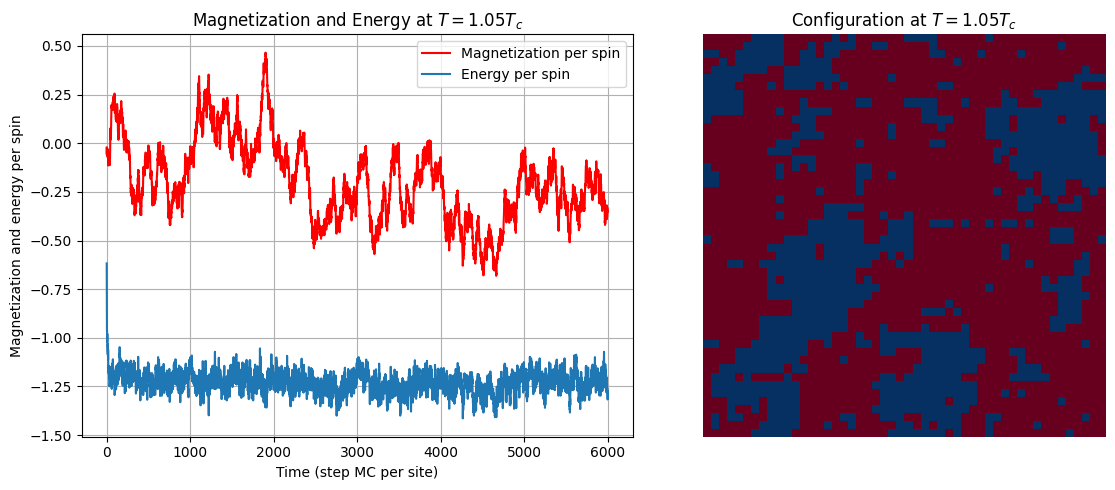

In [80]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].plot(magnetization2, color='r',label = 'Magnetization per spin' )
ax[0].plot(energy2, label = 'Energy per spin')
ax[0].set_title("Magnetization and Energy at $T = 1.05 T_c$")
ax[0].set_xlabel("Time (step MC per site)")
ax[0].set_ylabel("Magnetization and energy per spin")
ax[0].grid(True)
ax[0].legend()

ax[1].imshow(lattice2, cmap='RdBu')
ax[1].set_title("Configuration at $T = 1.05 T_c$")
ax[1].axis('off')
plt.tight_layout()
plt.show()

In [91]:
magnetiz_eq = magnetization2[200:]
energy_eq = energy2[200:] 
magnetization2 = magnetiz_eq
energy2 = energy_eq

In [92]:
M2, sigma_M2, chi_M2, E2, sigma_E2, C_V2 = Averages(1.05*Tc, L, magnetization2, energy2) 
print('Average of the magnetization  ' f"{M2}1 \u00B1 {sigma_M2}")
print('Average of the energy  ' f"{E2} \u00B1 {sigma_E2}")
print('Magnetic susceptibility  ', chi_M2)
print('Specific heat   ', C_V2)
fin_chi50, fin_C50, sigma_chi50, sigma_C50 = Fluctuations(1.05*Tc, L,magnetization2, energy2, 10)
print('Final susceptiblity (blocks)  ' f"{fin_chi50}1 \u00B1 {sigma_chi50}")
print('Final specific heat (blocks)  ' f"{fin_C50} \u00B1 {sigma_C50}")

Average of the magnetization  -0.208354526315789851 ± 0.002674073895562634
Average of the energy  -1.2309827368421051 ± 0.0006870506681010433
Magnetic susceptibility   42.76637205705682
Specific heat    0.0004739514558330498
Final susceptiblity (blocks)  17.9906892205431571 ± 2.55209433856842
Final specific heat (blocks)  0.0004131783985230025 ± 2.4705852096077347e-05


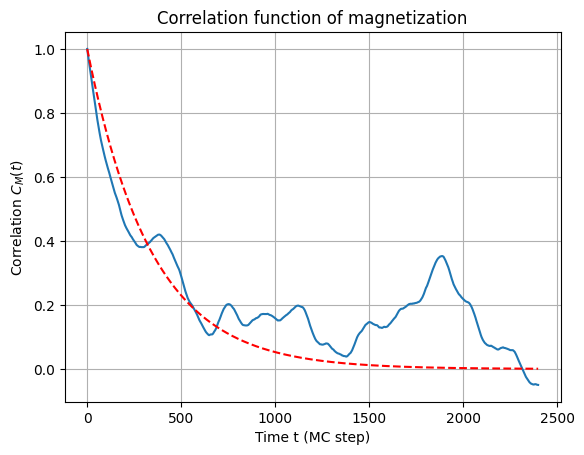

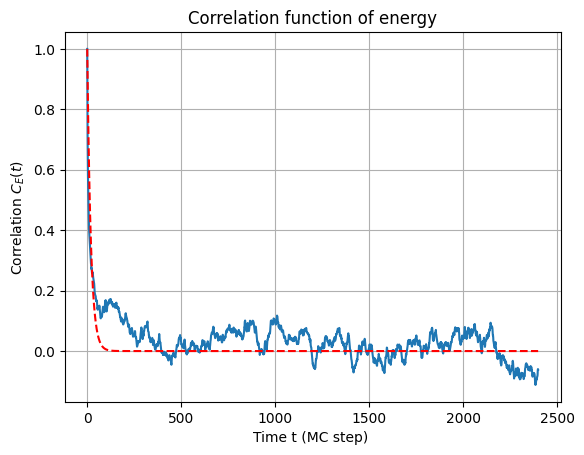

fit correlation time for energy  19.208386784011466
fit correlation time for magnetization  339.9753711266496


In [81]:
# Calculation Correlation function
C_M2 = corr_function_long(magnetization2)
C_E2 = corr_function_long(energy2)

C_m_norm2 = np.array([x2 / C_M2[0] for x2 in C_M2])
C_e_norm2 = np.array([y2 / C_E2[0] for y2 in C_E2])


def exp_decay(t, a):
    return np.exp(-t / a)

t = np.arange(len(C_e_norm2))

fit_set_e2 = (t >= 0) & (t <= 100)    # Energy correlation function fit
x_fit_e2 = t[fit_set_e2]
C_e_fit2 = C_e_norm2[fit_set_e2]
popt, pcov = curve_fit(exp_decay, x_fit_e2, C_e_fit2)  
a_fit_e2 = popt[0]  
exp_E2 = exp_decay(t, a_fit_e2)

fit_set_m2 = (t >= 0) & (t <= 800)    # Magnetization correlation function fit
x_fit_m2 = t[fit_set_m2]
C_m_fit2 = C_m_norm2[fit_set_m2]
popt, pcov = curve_fit(exp_decay, x_fit_m2, C_m_fit2)  
a_fit_m2 = popt[0]  
exp_M2 = exp_decay(t, a_fit_m2)

# Grafico della funzione di correlazione
plt.plot(C_m_norm2)
plt.plot(t, exp_M2, color='red', linestyle='--')
plt.xlabel("Time t (MC step)")
plt.ylabel("Correlation $C_M(t)$")
plt.title("Correlation function of magnetization")
#plt.yscale('log')
#plt.xlim(-10,200)
plt.grid()
plt.show()

plt.plot(C_e_norm2)
plt.plot(t, exp_E2, color='red', linestyle='--')
plt.xlabel("Time t (MC step) ")
plt.ylabel("Correlation $C_E(t)$")
plt.title("Correlation function of energy")
#plt.xlim(-5,300)
plt.grid()
plt.show()

print('fit correlation time for energy ', a_fit_e2)
print('fit correlation time for magnetization ', a_fit_m2)

In [82]:
s2 = 0
for i in range(900):
    s2 += C_m_norm2[i]

print('correlation time for magnetization, critical temperature  ',s2)

l2 = 0
for i in range(125):
    l2 += C_e_norm2[i]

print('correlation time for the energy, critical temperature  ',l2)

correlation time for magnetization, critical temperature   318.82061728129776
correlation time for the energy, critical temperature   27.20962875800652


In [93]:
# New errors estimated for energy and magnetization. in this case the correlation time tau > delta_t, not exactly tau >> delta_t
tcorr_e2 = 13 # Estimate of correlation time for the magnetization 
tcorr_m2 = 240 # Estimate of correlation time  for the energy

sum_m2 = 0
sum_e2 = 0
ssum_m2 = 0
ssum_e2 = 0
N = L**2

# NEW ERROR BARS 
for i in range(len(magnetization2)):  
    x = magnetization2[i]
    sum_m2 += x
    ssum_m2 += x**2
    
    y = energy2[i]
    sum_e2 += y
    ssum_e2 += y**2
# for the magnetization
sigma_magnetiz_new2 = math.sqrt((1 + 2 * tcorr_m2/1)*(ssum_m2 / len(magnetization2) - (sum_m2 / len(magnetization2))**2) / len(magnetization2))
print('new error bars for the magnetization  ', sigma_magnetiz_new2)

# for the energy
sigma_energy_new2 = math.sqrt((1 + 2 * tcorr_e2/1)*(ssum_e2 / len(energy2)  - (sum_e2 / len(energy2))**2) / len(energy2))
print('new error bars for the energy  ', sigma_energy_new2)

new error bars for the magnetization   0.05864701907757204
new error bars for the energy   0.003570019993575446


--------------------------------------------------------------$T = 1.2T_c$--------------------------------------------------------------------

SIMULATION L=50, HIGH TEMPERATURE

In [94]:
L = 50
time = 4000

In [95]:
lattice1 = np.random.choice([-1,1], size=(L,L)) 
lattice1, magnetization1, energy1 = Ising(lattice1, 1.2*Tc, L, time)

PLOT ENERGY AND MAGNETIZATION + LATTICE AT THE END 

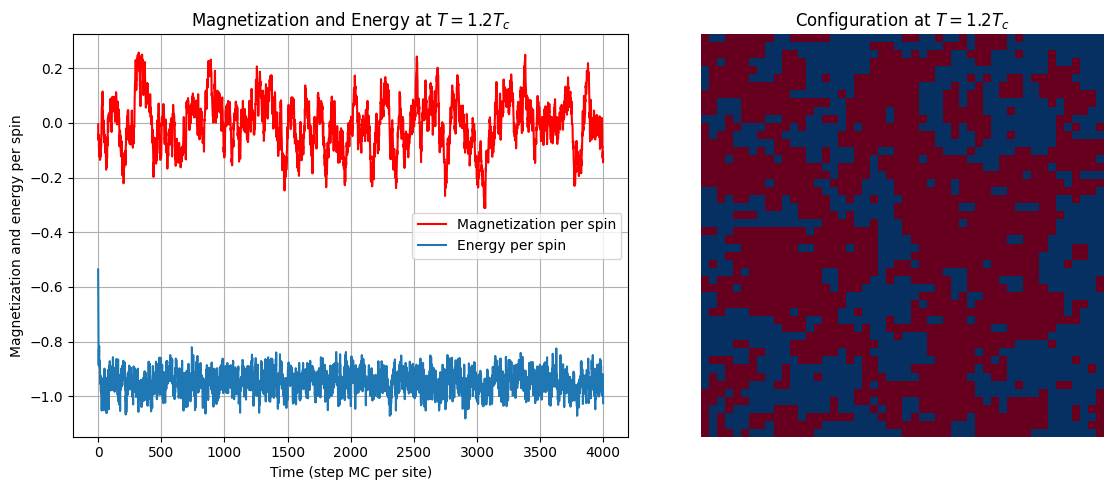

In [96]:

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].plot(magnetization1, color='r',label = 'Magnetization per spin' )
ax[0].plot(energy1, label = 'Energy per spin')
ax[0].set_title("Magnetization and Energy at $T = 1.2 T_c$")
ax[0].set_xlabel("Time (step MC per site)")
ax[0].set_ylabel("Magnetization and energy per spin")
ax[0].grid(True)
ax[0].legend()

ax[1].imshow(lattice1, cmap='RdBu')
ax[1].set_title("Configuration at $T = 1.2 T_c$")
ax[1].axis('off')
plt.tight_layout()
plt.show()

AVERAGES

In [106]:
M1, sigma_M1, chi_M1, E1, sigma_E1, C_V1 = Averages(1.2*Tc, L, magnetization1, energy1) 
print('Average of the magnetization  ' f"{M1}1 \u00B1 {sigma_M1}")
print('Average of the energy  ' f"{E1} \u00B1 {sigma_E1}")
print('Magnetic susceptibility  ', chi_M1)
print('Specific heat   ', C_V1)
fin_chi50, fin_C50, sigma_chi50, sigma_C50 = Fluctuations(1.2*Tc, L,magnetization1, energy1, 20)
print('Final susceptiblity (blocks)  ' f"{fin_chi50}1 \u00B1 {sigma_chi50}")
print('Final specific heat (blocks)  ' f"{fin_C50} \u00B1 {sigma_C50}")


Average of the magnetization  -0.0048820000000000011 ± 0.0014759267458109115
Average of the energy  -0.9486136000000023 ± 0.0006581418340733282
Magnetic susceptibility   7.999786477536857
Specific heat    0.0002336665600365577
Final susceptiblity (blocks)  6.3229962724791351 ± 0.60692065262985
Final specific heat (blocks)  0.00022896624931422488 ± 1.7149996024845766e-05


CORRELATION FUNCTIONS + ESTIMATION OF THE CORRELATION TIME

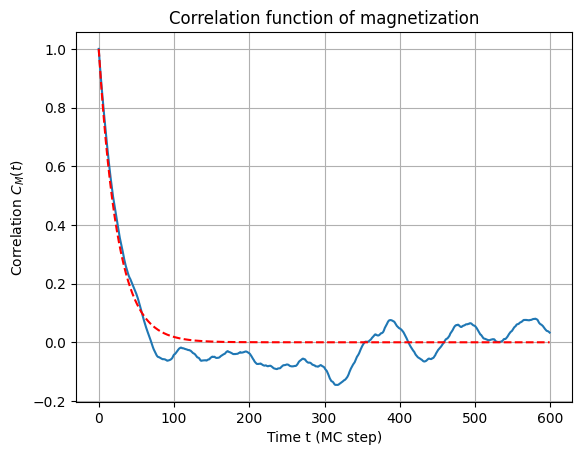

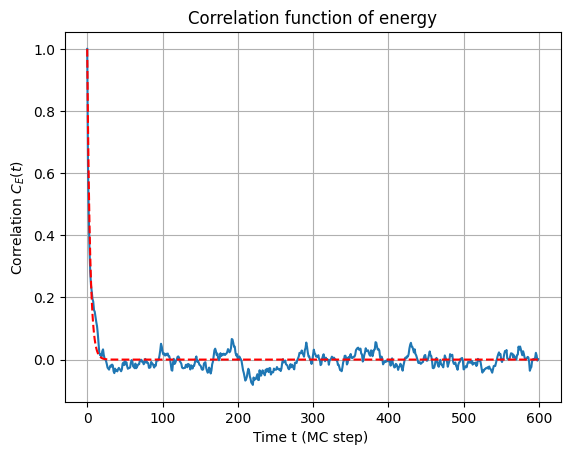

fit correlation time for energy  3.6326413923510374
fit correlation time for magnetization  24.938751723259003


In [97]:
# Calculation Correlation function
C_M1 = corr_function(magnetization1)
C_E1 = corr_function(energy1)

C_m_norm1 = np.array([x1 / C_M1[0] for x1 in C_M1])
C_e_norm1 = np.array([y1 / C_E1[0] for y1 in C_E1])


def exp_decay(t, a):
    return np.exp(-t / a)

t = np.arange(len(C_e_norm1))

fit_set_e1 = (t >= 0) & (t <= 50)    # Energy correlation function fit
x_fit_e1 = t[fit_set_e1]
C_e_fit1 = C_e_norm1[fit_set_e1]
popt, pcov = curve_fit(exp_decay, x_fit_e1, C_e_fit1)  
a_fit_e1 = popt[0]  
exp_E1 = exp_decay(t, a_fit_e1)

fit_set_m1 = (t >= 0) & (t <= 300)    # Magnetization correlation function fit
x_fit_m1 = t[fit_set_m1]
C_m_fit1 = C_m_norm1[fit_set_m1]
popt, pcov = curve_fit(exp_decay, x_fit_m1, C_m_fit1)  
a_fit_m1 = popt[0]  
exp_M1 = exp_decay(t, a_fit_m1)

# Grafico della funzione di correlazione
plt.plot(C_m_norm1)
plt.plot(t, exp_M1, color='red', linestyle='--')
plt.xlabel("Time t (MC step)")
plt.ylabel("Correlation $C_M(t)$")
plt.title("Correlation function of magnetization")
#plt.yscale('log')
#plt.xlim(-10,200)
plt.grid()
plt.show()

plt.plot(C_e_norm1)
plt.plot(t, exp_E1, color='red', linestyle='--')
plt.xlabel("Time t (MC step) ")
plt.ylabel("Correlation $C_E(t)$")
plt.title("Correlation function of energy")
#plt.xlim(-5,50)
plt.grid()
plt.show()

print('fit correlation time for energy ', a_fit_e1)
print('fit correlation time for magnetization ', a_fit_m1)

second method

In [98]:
s = 0
for i in range(125):
    s += C_m_norm1[i]

print('magnetization correlation time  ',s)

l = 0
for i in range(250):
    l += C_e_norm1[i]

print('energy correlation time   ',l)

magnetization correlation time   22.935778792566417
energy correlation time    1.2471200670129705


NEW ERRORBARS FOR ENERGY AND MAGNETIZATION 

In [99]:
tcorr_e1 = 3 # Estimate of correlation time for the magnetization 
tcorr_m1 = 33 # Estimate of correlation time  for the energy

sum_m1 = 0
sum_e1 = 0
ssum_m1 = 0
ssum_e1 = 0
N = L**2

# NEW ERROR BARS 
for i in range(len(magnetization1)):  
    x = magnetization1[i]
    sum_m1 += x
    ssum_m1 += x**2
    
    y = energy1[i]
    sum_e1 += y
    ssum_e1 += y**2
# for the magnetization
sigma_magnetiz_new1 = math.sqrt((1 + 2 * tcorr_m1/1)*(ssum_m1 / len(magnetization1) - (sum_m1 / len(magnetization1))**2) / len(magnetization1))
print('new error bars for the magnetization  ', sigma_magnetiz_new1)

# for the energy
sigma_energy_new1 = math.sqrt((1 + 2 * tcorr_e1/1)*(ssum_e1 / len(energy1)  - (sum_e1 / len(energy1))**2) / len(energy1))
print('new error bars for the energy  ', sigma_energy_new1)

new error bars for the magnetization   0.012080981079904029
new error bars for the energy   0.0017412796203659623


------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

# L = 25

--------------------------------------------------------------------------------------$ T = 0.8*T_c$--------------------------------------------------------------------------------------

SIMULATION L=25, LOW TEMPERATURE

In [93]:
time_small = 2000
L_small = 25
lattice3 = np.random.choice([-1,1], size=(L_small,L_small)) 
lattice3, magnetization3, energy3 = Ising(lattice3, 0.8*Tc, L_small, time_small)

PLOT ENERGY AND MAGNETIZATION + LATTICE AT THE END

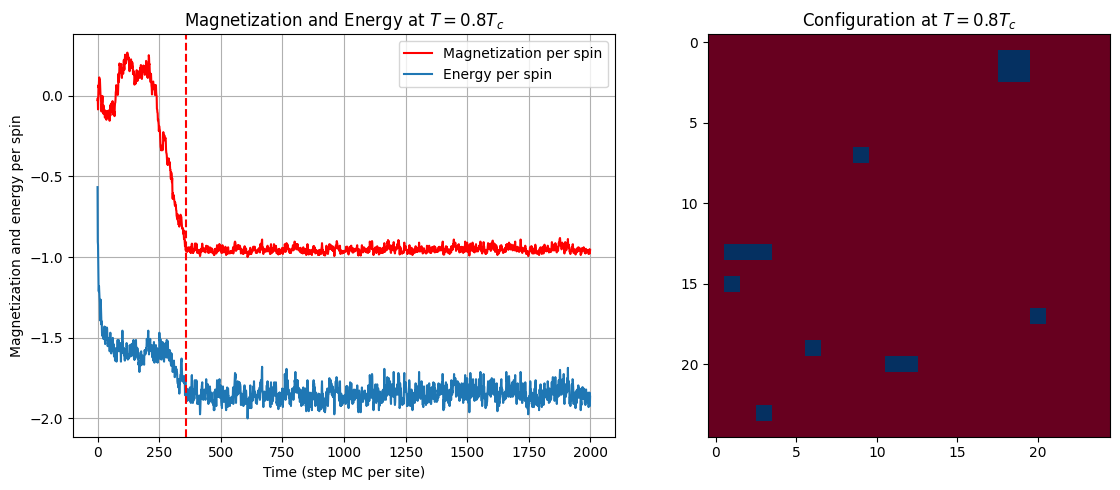

In [102]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].plot(magnetization3, color='r',label = 'Magnetization per spin' )
ax[0].plot(energy3, label = 'Energy per spin')
ax[0].set_title("Magnetization and Energy at $T = 0.8 T_c$")
ax[0].set_xlabel("Time (step MC per site)")
ax[0].set_ylabel("Magnetization and energy per spin")
#ax[0].set_xlim(0, 500)
ax[0].axvline(x=360, color='red', linestyle='--')
ax[0].grid(True)
ax[0].legend()

ax[1].imshow(lattice3, cmap='RdBu')
ax[1].set_title("Configuration at $T = 0.8 T_c$")
plt.tight_layout()
plt.show()

SAVING AND LOADING DATA

In [104]:
# SAVING
save_data(lattice3, magnetization3, energy3, "lattice_T108_L25.npy", "M_T08_L25.npy","E_T08_L25.npy")

Dati salvati:
- lattice_T108_L25.npy
- M_T08_L25.npy
- E_T08_L25.npy


In [54]:
# LOADING
lattice3_a, magnetization3_a, energy3_a = load_data("lattice_T108_L25.npy", "M_T08_L25.npy","E_T08_L25.npy")

Dati caricati:
- lattice_T108_L25.npy
- M_T08_L25.npy
- E_T08_L25.npy


DATA AFTER EQUILIBRATION ONLY

In [55]:
t_eq = 360
magnetiz_eq3 = magnetization3_a[360:]
energy_eq3 = energy3_a[360:]

AVERAGES

In [56]:
M3, sigma_M3, chi_M3, E3, sigma_E3, C_V3 = Averages(0.8*Tc, L_small, magnetiz_eq3, energy_eq3) 
print('Average of the magnetization  ' f"{M3} \u00B1 {sigma_M3}")
print('Average of the energy  ' f"{E3} \u00B1 {sigma_E3}")
print('Magnetic susceptibility  ', chi_M3)
print('Specific heat   ', C_V3)
fin_chi25, fin_C25, sigma_chi25, sigma_C25 = Fluctuations(0.8*Tc, L_small, magnetiz_eq3, energy_eq3, 20)
print('Final susceptiblity (blocks)  ' f"{fin_chi25}1 \u00B1 {sigma_chi25}")
print('Final specific heat (blocks)  ' f"{fin_C25} \u00B1 {sigma_C25}")

Average of the magnetization  -0.9526048780487794 ± 0.0004543929117728435
Average of the energy  -1.847348292682924 ± 0.001215138268268707
Magnetic susceptibility   0.11658079438277139
Specific heat    0.0007348104809031739
Final susceptiblity (blocks)  0.104368946503788061 ± 0.0062393698823862845
Final specific heat (blocks)  0.0006729460303237621 ± 2.535314591343065e-05


CORRELATION FUNCTIONS + ESTIMATION OF THE CORRELATION TIME

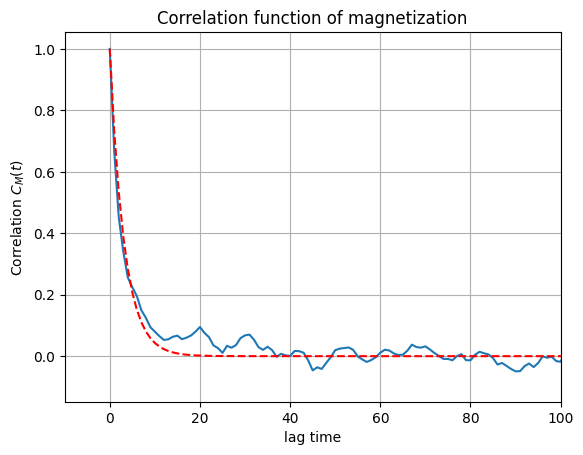

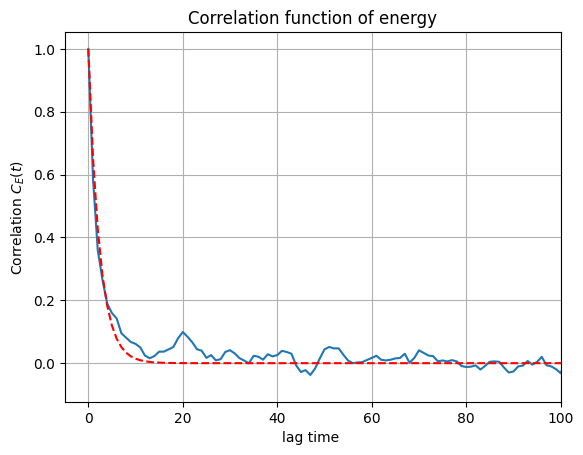

fit correlation time for energy  2.355224004583737
fit correlation time for magnetization  3.1770948937635723


In [112]:
# Calculation Correlation function
C_M3 = corr_function(magnetiz_eq3)
C_E3 = corr_function(energy_eq3)

C_m_norm3 = np.array([x1 / C_M3[0] for x1 in C_M3])
C_e_norm3 = np.array([y1 / C_E3[0] for y1 in C_E3])


def exp_decay(t, a):
    return np.exp(-t / a)

t = np.arange(len(C_e_norm3))

fit_set_e3 = (t >= 0) & (t <= 50)    # Energy correlation function fit
x_fit_e3 = t[fit_set_e3]
C_e_fit3 = C_e_norm3[fit_set_e3]
popt, pcov = curve_fit(exp_decay, x_fit_e3, C_e_fit3)  
a_fit_e3 = popt[0]  
exp_E3 = exp_decay(t, a_fit_e3)

fit_set_m3 = (t >= 0) & (t <= 100)    # Magnetization correlation function fit
x_fit_m3 = t[fit_set_m3]
C_m_fit3 = C_m_norm3[fit_set_m3]
popt, pcov = curve_fit(exp_decay, x_fit_m3, C_m_fit3)  
a_fit_m3 = popt[0]  
exp_M3 = exp_decay(t, a_fit_m3)

# Grafico della funzione di correlazione
plt.plot(C_m_norm3)
plt.plot(t, exp_M3, color='red', linestyle='--')
plt.xlabel("lag time")
plt.ylabel("Correlation $C_M(t)$")
plt.title("Correlation function of magnetization")
#plt.yscale('log')
plt.xlim(-10,100)
plt.grid()
plt.show()

plt.plot(C_e_norm3)
plt.plot(t, exp_E3, color='red', linestyle='--')
plt.xlabel("lag time ")
plt.ylabel("Correlation $C_E(t)$")
plt.title("Correlation function of energy")
plt.xlim(-5,100)
plt.grid()
plt.show()

print('fit correlation time for energy ', a_fit_e3)
print('fit correlation time for magnetization ', a_fit_m3)

In [118]:
s = 0
for i in range(40):
    s += C_m_norm3[i]

print('magnetization correlation time  ',s)

l = 0
for i in range(60):
    l += C_e_norm3[i]

print('energy correlation time   ',l)

magnetization correlation time   4.9066391872018675
energy correlation time    4.278205086499342


NEW ERROR BARS FOR ENERGY AND MAGNETIZATION

In [120]:
tcorr_e3 = 3.4 # Estimate of correlation time for the magnetization 
tcorr_m3 = 4 # Estimate of correlation time  for the energy

NewErrors(tcorr_m3, tcorr_e3, magnetiz_eq3, energy_eq3, L_small)

new error bars for the magnetization   0.0013631787353185305
new error bars for the energy   0.003393696492894785


---------------------------------------------------------------------------------$T = 1.05 T_c$-------------------------------------------------------------------------------

SIMULATION L=25, NEAR CRITICAL TEMPERATURE

In [95]:
time_small = 4000 # a longer time is chosen because of the critical slowing down 
L_small = 25
lattice4 = np.random.choice([-1,1], size=(L_small,L_small)) 
lattice4, magnetization4, energy4 = Ising(lattice4, 1.05*Tc, L_small, time_small)

PLOT ENERGY AND MAGNETIZATION + LATTICE AT THE END 

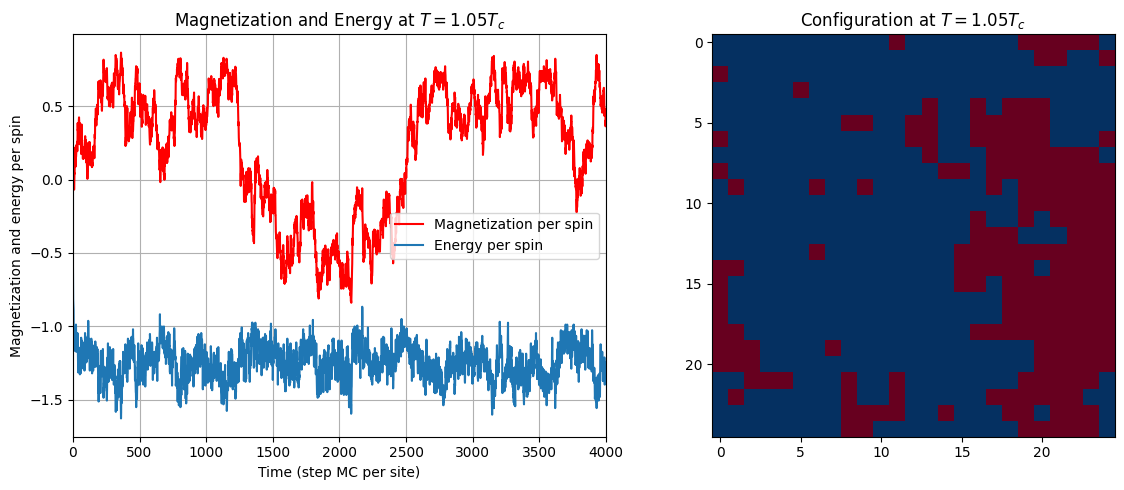

In [96]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].plot(magnetization4, color='r',label = 'Magnetization per spin' )
ax[0].plot(energy4, label = 'Energy per spin')
ax[0].set_title("Magnetization and Energy at $T = 1.05 T_c$")
ax[0].set_xlabel("Time (step MC per site)")
ax[0].set_ylabel("Magnetization and energy per spin")
ax[0].set_xlim(0, 4000)
#ax[0].axvline(x=300, color='red', linestyle='--')
ax[0].grid(True)
ax[0].legend()

ax[1].imshow(lattice4, cmap='RdBu')
ax[1].set_title("Configuration at $T = 1.05 T_c$")
plt.tight_layout()
plt.show()

SAVING AND LOADING DATA

In [121]:
save_data(lattice4, magnetization4, energy4, "lattice_T105_L25.npy", "M_T105_L25.npy","E_T105_L25.npy")

Dati salvati:
- lattice_T105_L25.npy
- M_T105_L25.npy
- E_T105_L25.npy


In [57]:
lattice4_a, magnetization4_a, energy4_a = load_data("lattice_T105_L25.npy", "M_T105_L25.npy","E_T105_L25.npy")

Dati caricati:
- lattice_T105_L25.npy
- M_T105_L25.npy
- E_T105_L25.npy


In [58]:
# DISCARDING DATA AFTER EQUILIBRATION TIME
magnetization4a = magnetization4_a
energy4a = energy4_a

AVERAGES

In [62]:
# AVERAGES
M4, sigma_M4, chi_M4, E4, sigma_E4, C_V4 = Averages(1.05*Tc, L_small, magnetization4a, energy4a) 
print('Average of the magnetization  ' f"{M4}1 \u00B1 {sigma_M4}")
print('Average of the energy  ' f"{E4} \u00B1 {sigma_E4}")
print('Magnetic susceptibility  ', chi_M4)
print('Specific heat   ', C_V4)
fin_chi25, fin_C25, sigma_chi25, sigma_C25 = Fluctuations(1.05*Tc, L_small, magnetization4a, energy4a, 4)
print('Final susceptiblity (blocks)  ' f"{fin_chi25}1 \u00B1 {sigma_chi25}")
print('Final specific heat (blocks)  ' f"{fin_C25} \u00B1 {sigma_C25}")

Average of the magnetization  0.226361599999999831 ± 0.006869152817586762
Average of the energy  -1.2482368000000024 ± 0.0018152650664395682
Magnetic susceptibility   49.509336000999056
Specific heat    0.0023217826675487885
Final susceptiblity (blocks)  33.926009526519161 ± 10.897633067365678
Final specific heat (blocks)  0.0023007151367075954 ± 0.00012865317165219753


CORRELATION FUNCTIONS + ESTIMATION CORRELATION TIME

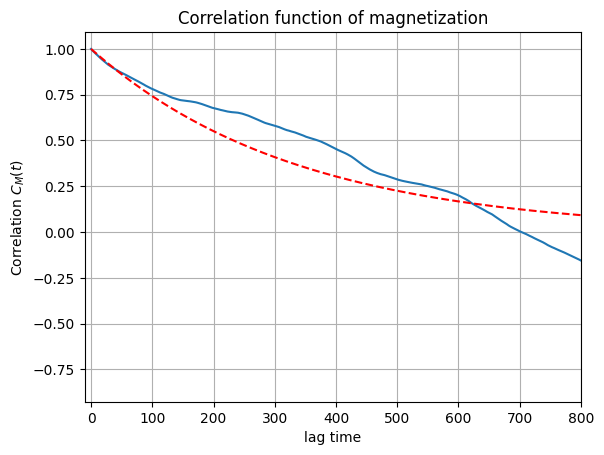

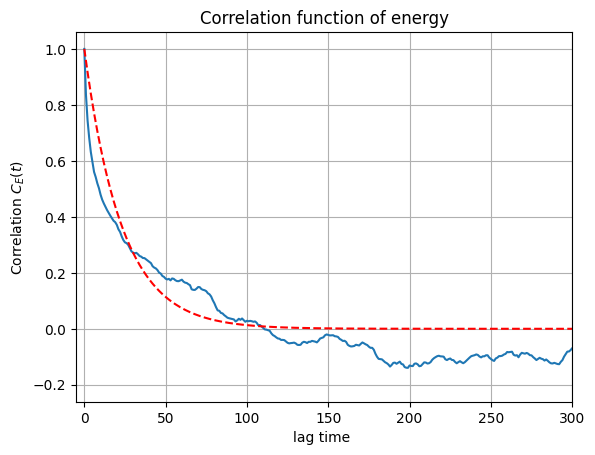

fit correlation time for energy  23.013530367469627
fit correlation time for magnetization  335.4591111209895


In [132]:

# Calculation Correlation function
C_M4 = corr_function_long(magnetization4a)
C_E4 = corr_function_long(energy4a)

C_m_norm4 = np.array([x1 / C_M4[0] for x1 in C_M4])
C_e_norm4 = np.array([y1 / C_E4[0] for y1 in C_E4])


def exp_decay(t, a):
    return np.exp(-t / a)

t = np.arange(len(C_e_norm4))

fit_set_e4 = (t >= 0) & (t <= 200)    # Energy correlation function fit
x_fit_e4 = t[fit_set_e4]
C_e_fit4 = C_e_norm4[fit_set_e4]
popt, pcov = curve_fit(exp_decay, x_fit_e4, C_e_fit4)  
a_fit_e4 = popt[0]  
exp_E4 = exp_decay(t, a_fit_e4)

fit_set_m4 = (t >= 0) & (t <= 1000)    # Magnetization correlation function fit
x_fit_m4 = t[fit_set_m4]
C_m_fit4 = C_m_norm4[fit_set_m4]
popt, pcov = curve_fit(exp_decay, x_fit_m4, C_m_fit4)  
a_fit_m4 = popt[0]  
exp_M4 = exp_decay(t, a_fit_m4)

# Grafico della funzione di correlazione
plt.plot(C_m_norm4)
plt.plot(t, exp_M4, color='red', linestyle='--')
plt.xlabel("lag time")
plt.ylabel("Correlation $C_M(t)$")
plt.title("Correlation function of magnetization")
#plt.yscale('log')
plt.xlim(-10,800)
plt.grid()
plt.show()

plt.plot(C_e_norm4)
plt.plot(t, exp_E4, color='red', linestyle='--')
plt.xlabel("lag time ")
plt.ylabel("Correlation $C_E(t)$")
plt.title("Correlation function of energy")
plt.xlim(-5,300)
plt.grid()
plt.show()

print('fit correlation time for energy ', a_fit_e4)
print('fit correlation time for magnetization ', a_fit_m4)

In [131]:
s = 0
for i in range(700):
    s += C_m_norm4[i]

print('magnetization correlation time  ',s)

l = 0
for i in range(110):
    l += C_e_norm4[i]

print('energy correlation time   ',l)

magnetization correlation time   347.3902354355286
energy correlation time    24.494128363058728


NEW ERROR BARS FOR ENERGY AND MAGNETIZATION

In [151]:
tcorr_e4 = 24.5 # Estimate of correlation time for the magnetization 
tcorr_m4 = 347 # Estimate of correlation time  for the energy

NewErrors(tcorr_m4, tcorr_e4, magnetization4a, energy4a, L_small)


new error bars for the magnetization   0.18109046358048594
new error bars for the energy   0.012835862381304675


----------------------------------------------------------------------------      $T = 1.2T_C$          -------------------------------------------------------------------------------

SIMULATION L=25, HIGH TEMPERATURE

In [97]:
time_small = 2000
L_small = 25
lattice5 = np.random.choice([-1,1], size=(L_small,L_small)) 
lattice5, magnetization5, energy5 = Ising(lattice5, 1.2*Tc, L_small, time_small)

PLOT ENERGY AND MAGNETIZATION + LATTICE AT THE END 

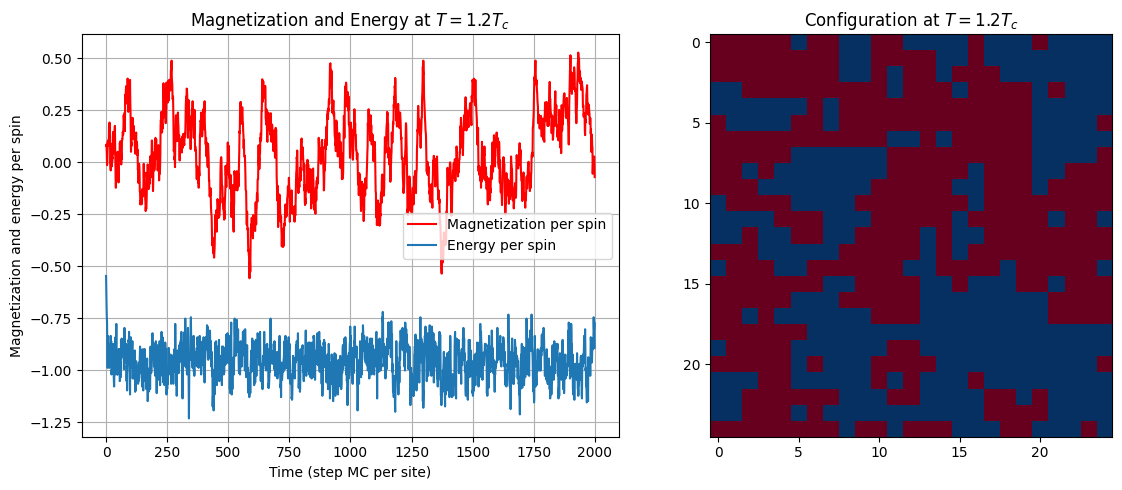

In [99]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].plot(magnetization5, color='r',label = 'Magnetization per spin' )
ax[0].plot(energy5, label = 'Energy per spin')
ax[0].set_title("Magnetization and Energy at $T = 1.2 T_c$")
ax[0].set_xlabel("Time (step MC per site)")
ax[0].set_ylabel("Magnetization and energy per spin")
#ax[0].set_xlim(0, 500)
ax[0].grid(True)
ax[0].legend()

ax[1].imshow(lattice5, cmap='RdBu')
ax[1].set_title("Configuration at $T = 1.2 T_c$")
plt.tight_layout()
plt.show()

SAVING AND LOADING DATA

In [138]:
# saving
save_data(lattice5, magnetization5, energy5, "lattice_T12_L25.npy", "M_T12_L25.npy","E_T12_L25.npy")

Dati salvati:
- lattice_T12_L25.npy
- M_T12_L25.npy
- E_T12_L25.npy


In [63]:
# loading
lattice5_a, magnetization5_a, energy5_a = load_data("lattice_T12_L25.npy", "M_T12_L25.npy","E_T12_L25.npy")
magnetization5 = magnetization5_a
energy5 = energy5_a

Dati caricati:
- lattice_T12_L25.npy
- M_T12_L25.npy
- E_T12_L25.npy


AVERAGES

In [70]:
# AVERAGES 

M5, sigma_M5, chi_M5, E5, sigma_E5, C_V5 = Averages(1.2*Tc, L_small, magnetization5, energy5) 
print('Average of the magnetization  ' f"{M5}1 \u00B1 {sigma_M5}")
print('Average of the energy  ' f"{E5} \u00B1 {sigma_E5}")
print('Magnetic susceptibility  ', chi_M5)
print('Specific heat   ', C_V5)
fin_chi25, fin_C25, sigma_chi25, sigma_C25 = Fluctuations(1.2*Tc, L_small, magnetization5, energy5, 10)
print('Final susceptiblity (blocks)  ' f"{fin_chi25}1 \u00B1 {sigma_chi25}")
print('Final specific heat (blocks)  ' f"{fin_C25} \u00B1 {sigma_C25}")

Average of the magnetization  0.0381167999999999651 ± 0.004442642049375569
Average of the energy  -0.9580896000000011 ± 0.0018780368861971925
Magnetic susceptibility   9.060276434553865
Specific heat    0.0009513401172007031
Final susceptiblity (blocks)  6.5599050608298031 ± 0.724894509075296
Final specific heat (blocks)  0.0009347495459189746 ± 5.1493230492708744e-05


CORRELATION FUNCTIONS AND ESTIMATION OF CORRELATION TIME

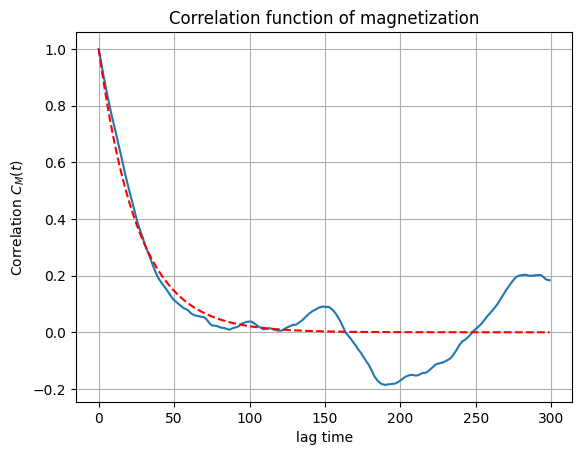

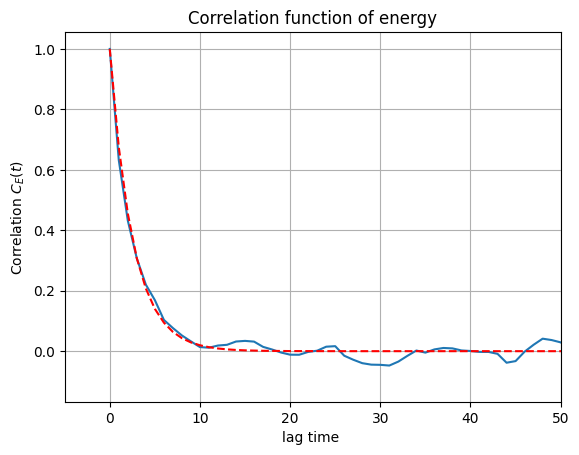

fit correlation time for energy  2.5425723228125197
fit correlation time for magnetization  25.988316751993597
magnetization correlation time   25.165327032827534
energy correlation time    2.9650235613785108


In [148]:
# Calculation Correlation function
C_M5 = corr_function(magnetization5)
C_E5 = corr_function(energy5)

C_m_norm5 = np.array([x1 / C_M5[0] for x1 in C_M5])
C_e_norm5 = np.array([y1 / C_E5[0] for y1 in C_E5])


def exp_decay(t, a):
    return np.exp(-t / a)

t = np.arange(len(C_e_norm5))

fit_set_e5 = (t >= 0) & (t <= 100)    # Energy correlation function fit
x_fit_e5 = t[fit_set_e5]
C_e_fit5 = C_e_norm5[fit_set_e5]
popt, pcov = curve_fit(exp_decay, x_fit_e5, C_e_fit5)  
a_fit_e5 = popt[0]  
exp_E5 = exp_decay(t, a_fit_e5)

fit_set_m5 = (t >= 0) & (t <= 250)    # Magnetization correlation function fit
x_fit_m5 = t[fit_set_m5]
C_m_fit5 = C_m_norm5[fit_set_m5]
popt, pcov = curve_fit(exp_decay, x_fit_m5, C_m_fit5)  
a_fit_m5 = popt[0]  
exp_M5 = exp_decay(t, a_fit_m5)

# Grafico della funzione di correlazione
plt.plot(C_m_norm5)
plt.plot(t, exp_M5, color='red', linestyle='--')
plt.xlabel("lag time")
plt.ylabel("Correlation $C_M(t)$")
#plt.axvline(x=80, color='red', linestyle='--')
plt.title("Correlation function of magnetization")
#plt.yscale('log')
#plt.xlim(-10,200)
plt.grid()
plt.show()

plt.plot(C_e_norm5)
plt.plot(t, exp_E5, color='red', linestyle='--')
plt.xlabel("lag time ")
plt.ylabel("Correlation $C_E(t)$")
plt.title("Correlation function of energy")
plt.xlim(-5,50)
plt.grid()
plt.show()

print('fit correlation time for energy ', a_fit_e5)
print('fit correlation time for magnetization ', a_fit_m5)

s = 0
for i in range(80):
    s += C_m_norm5[i]

print('magnetization correlation time  ',s)

l = 0
for i in range(40):
    l += C_e_norm5[i]

print('energy correlation time   ',l)

NEW ERROR BARS FOR MAGNETIZATION AND ENERGY

In [150]:
tcorr_e5 = 3 # Estimate of correlation time for the magnetization 
tcorr_m5 = 25.5 # Estimate of correlation time  for the energy
NewErrors(tcorr_m5, tcorr_e5, magnetization5, energy5, L_small)


new error bars for the magnetization   0.03203634741511207
new error bars for the energy   0.004968818553883884


-------------------------------------------------------------------------------------------------------------------------------------------------------------------------
-------------------------------------------------------------------------------------------------------------------------------------------------------------------------
-------------------------------------------------------------------------------------------------------------------------------------------------------------------------

# L = 75 

----------------------------------------------------------------------------------- $T = 0.8T_c$ -------------------------------------------------------------------------------------------

SIMULATION

In [11]:
time_big = 4000
L_big = 75
lattice6 = np.random.choice([-1,1], size=(L_big,L_big)) 
lattice6, magnetization6, energy6 = Ising(lattice6, 0.8*Tc, L_big, time_big)

KeyboardInterrupt: 

SAVING AND LOADING DATA

In [25]:
save_data(lattice6, magnetization6, energy6, "lattice_T08_L75.npy", "M_T08_L75.npy","E_T08_L75.npy")


Dati salvati:
- lattice_T08_L75.npy
- M_T08_L75.npy
- E_T08_L75.npy


In [14]:
lattice6_a, magnetization6_a, energy6_a = load_data("lattice_T08_L75.npy", "M_T08_L75.npy","E_T08_L75.npy")

Dati caricati:
- lattice_T08_L75.npy
- M_T08_L75.npy
- E_T08_L75.npy


PLOT MAGNETIZATION AND ENERGY + LATTICE AT THE END 

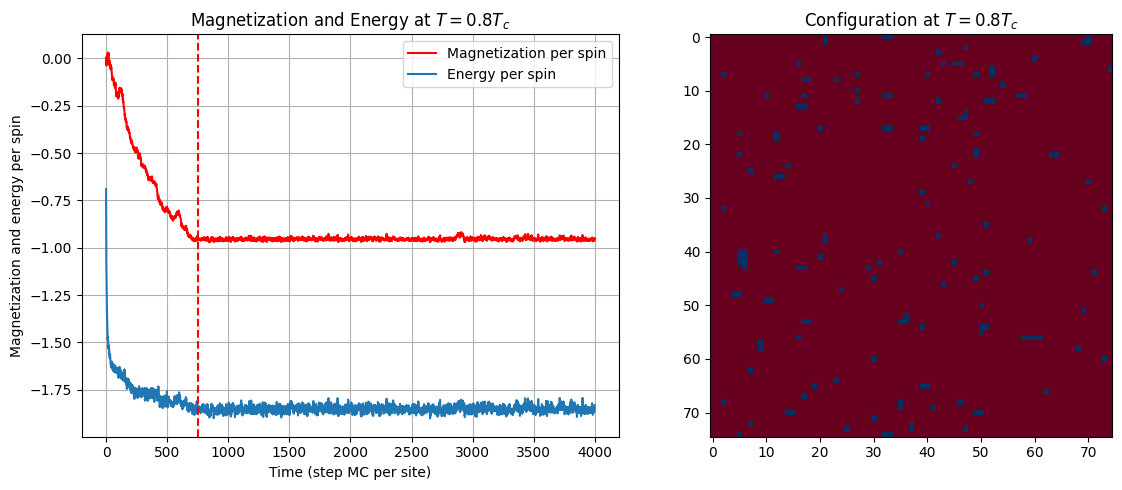

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].plot(magnetization6_a, color='r',label = 'Magnetization per spin' )
ax[0].plot(energy6_a, label = 'Energy per spin')
ax[0].set_title("Magnetization and Energy at $T = 0.8 T_c$")
ax[0].set_xlabel("Time (step MC per site)")
ax[0].set_ylabel("Magnetization and energy per spin")
#ax[0].set_xlim(0, 1700)
ax[0].axvline(x=750, color='red', linestyle='--')
ax[0].grid(True)
ax[0].legend()

ax[1].imshow(lattice6_a, cmap='RdBu')
ax[1].set_title("Configuration at $T = 0.8 T_c$")
plt.tight_layout()
plt.show()

DATA AFTER EQUILIBRATION ONLY

In [16]:
# After equilibration
t_eq = 750
magnetization6a = magnetization6_a[t_eq:]
energy6a = energy6_a[t_eq:]

AVERAGES

In [32]:
M6, sigma_M6, chi_M6, E6, sigma_E6, C_V6 = Averages(0.8*Tc, L_big, magnetization6a, energy6a) 
print('Average of the magnetization  ' f"{M6}1 \u00B1 {sigma_M6}")
print('Average of the energy  ' f"{E6} \u00B1 {sigma_E6}")
print('Magnetic susceptibility  ', chi_M6)
print('Specific heat   ', C_V6)
print(int(len(magnetization6a)/65))
fin_chi75, fin_C75, sigma_chi75, sigma_C75 = Fluctuations(0.8*Tc, L_big, magnetization6a, energy6a, 65)
print('Final susceptiblity (blocks)  ' f"{fin_chi75}1 \u00B1 {sigma_chi75}")
print('Final specific heat (blocks)  ' f"{fin_C75} \u00B1 {sigma_C75}")

Average of the magnetization  -0.95362100512820661 ± 0.0001236788699142371
Average of the energy  -1.8514044717948759 ± 0.0002896566747355872
Magnetic susceptibility   0.15404122129620146
Specific heat    8.274286223082327e-05
50
Final susceptiblity (blocks)  0.122147136148515981 ± 0.010468210941060728
Final specific heat (blocks)  7.430057135093847e-05 ± 2.8128966311451577e-06


CORRELATION FUNCTIONS AND ESTIMATION OF CORRELATION TIME

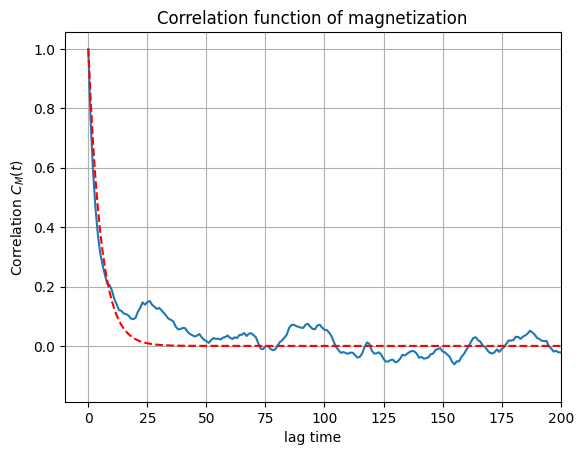

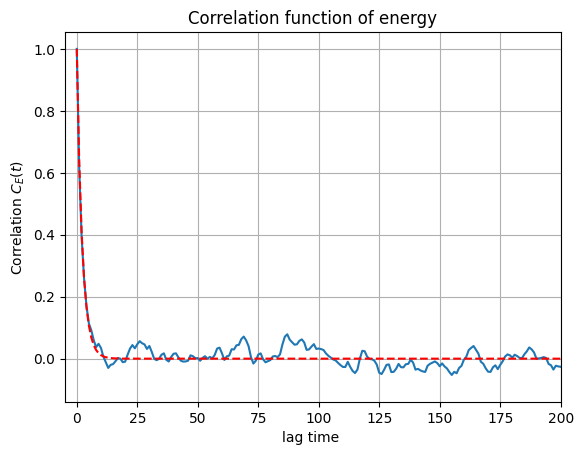

fit correlation time for energy  2.234166073033402
fit correlation time for magnetization  5.282140411134145
magnetization correlation time   8.908785345719723
energy correlation time    3.6683756994383314


In [43]:
# Calculation Correlation function
C_M6 = corr_function(magnetization6a)
C_E6 = corr_function(energy6a)

C_m_norm6 = np.array([x1 / C_M6[0] for x1 in C_M6])
C_e_norm6 = np.array([y1 / C_E6[0] for y1 in C_E6])


def exp_decay(t, a):
    return np.exp(-t / a)

t = np.arange(len(C_e_norm6))

fit_set_e6 = (t >= 0) & (t <= 100)    # Energy correlation function fit
x_fit_e6 = t[fit_set_e6]
C_e_fit6 = C_e_norm6[fit_set_e6]
popt, pcov = curve_fit(exp_decay, x_fit_e6, C_e_fit6)  
a_fit_e6 = popt[0]  
exp_E6 = exp_decay(t, a_fit_e6)

fit_set_m6 = (t >= 0) & (t <= 100)    # Magnetization correlation function fit
x_fit_m6 = t[fit_set_m6]
C_m_fit6 = C_m_norm6[fit_set_m6]
popt, pcov = curve_fit(exp_decay, x_fit_m6, C_m_fit6)  
a_fit_m6 = popt[0]  
exp_M6 = exp_decay(t, a_fit_m6)

# Grafico della funzione di correlazione
plt.plot(C_m_norm6)
plt.plot(t, exp_M6, color='red', linestyle='--')
plt.xlabel("lag time")
plt.ylabel("Correlation $C_M(t)$")
#plt.axvline(x=80, color='red', linestyle='--')
plt.title("Correlation function of magnetization")
#plt.yscale('log')
plt.xlim(-10,200)
plt.grid()
plt.show()

plt.plot(C_e_norm6)
plt.plot(t, exp_E6, color='red', linestyle='--')
plt.xlabel("lag time ")
plt.ylabel("Correlation $C_E(t)$")
plt.title("Correlation function of energy")
plt.xlim(-5,200)
plt.grid()
plt.show()

print('fit correlation time for energy ', a_fit_e6)
print('fit correlation time for magnetization ', a_fit_m6)

s = 0
for i in range(75):
    s += C_m_norm6[i]

print('magnetization correlation time  ',s)

l = 0
for i in range(75):
    l += C_e_norm6[i]

print('energy correlation time   ',l)

NEW ERRORS FOR MAGNETIZATION AND ENERGY

In [85]:
tcorr_e6 = 2.2 # Estimate of correlation time for the magnetization 
tcorr_m6 = 5.3 # Estimate of correlation time  for the energy

NewErrors(tcorr_m6, tcorr_e6, magnetization6a, energy6a, L_big)

new error bars for the magnetization   0.00042123505221413894
new error bars for the energy   0.0006731012864212488


----------------------------------------------------------------------------------- $T = 1.05T_c$ -------------------------------------------------------------------------------------------

In [11]:
time_big = 5000
L_big = 75
lattice7 = np.random.choice([-1,1], size=(L_big,L_big)) 
lattice7, magnetization7, energy7 = Ising(lattice7, 1.05*Tc, L_big, time_big)

SAVING DATA AND LOADING THEM

In [45]:
save_data(lattice7, magnetization7, energy7, "lattice_T105_L75.npy", "M_T105_L75.npy","E_T105_L75.npy")

Dati salvati:
- lattice_T105_L75.npy
- M_T105_L75.npy
- E_T105_L75.npy


In [33]:
lattice7_a, magnetization7_a, energy7_a = load_data("lattice_T105_L75.npy", "M_T105_L75.npy","E_T105_L75.npy")

Dati caricati:
- lattice_T105_L75.npy
- M_T105_L75.npy
- E_T105_L75.npy


PLOT ENERGY AND MAGNETIZATION + LATTICE AT THE END

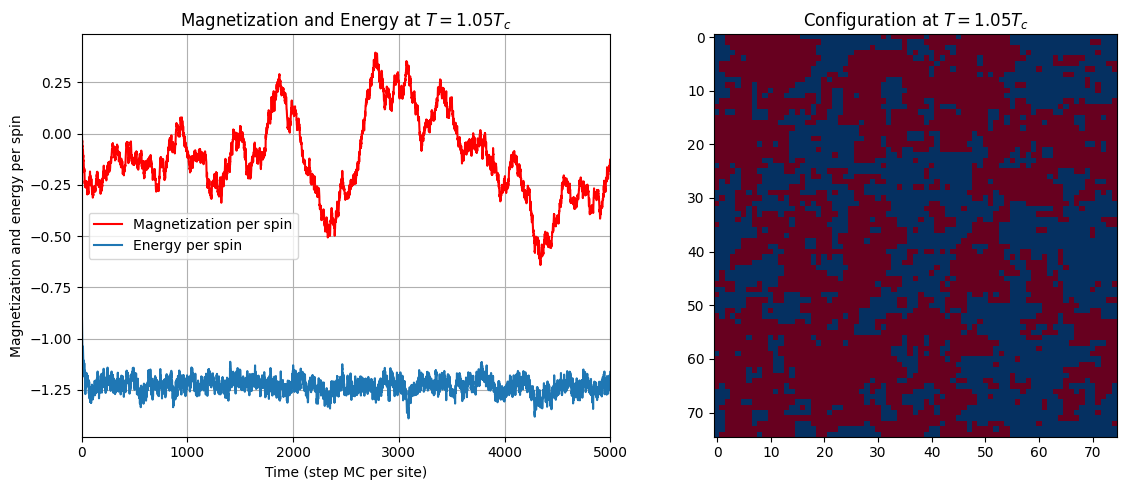

In [34]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].plot(magnetization7_a, color='r',label = 'Magnetization per spin' )
ax[0].plot(energy7_a, label = 'Energy per spin')
ax[0].set_title("Magnetization and Energy at $T = 1.05 T_c$")
ax[0].set_xlabel("Time (step MC per site)")
ax[0].set_ylabel("Magnetization and energy per spin")
ax[0].set_xlim(0, 5000)
ax[0].grid(True)
ax[0].legend()

ax[1].imshow(lattice7_a, cmap='RdBu')
ax[1].set_title("Configuration at $T = 1.05 T_c$")
plt.tight_layout()
plt.show()

FROM THE FILES, USE DATA

In [35]:
magnetization7a = magnetization7_a  
energy7a = energy7_a

AVERAGES

In [48]:
M7, sigma_M7, chi_M7, E7, sigma_E7, C_V7 = Averages(1.05*Tc, L_big, magnetization7a, energy7a) 
print('Average of the magnetization  ' f"{M7}1 \u00B1 {sigma_M7}")
print('Average of the energy  ' f"{E7} \u00B1 {sigma_E7}")
print('Magnetic susceptibility  ', chi_M7)
print('Specific heat   ', C_V7)
fin_chi752, fin_C752, sigma_chi752, sigma_C752 = Fluctuations(1.05*Tc, L_big, magnetization7a, energy7a, 10)
print('Final susceptiblity (blocks)  ' f"{fin_chi752}1 \u00B1 {sigma_chi752}")
print('Final specific heat (blocks)  ' f"{fin_C752} \u00B1 {sigma_C752}")

Average of the magnetization  -0.118292266666666561 ± 0.0028399299115833376
Average of the energy  -1.2302350222222214 ± 0.0005682095922997167
Magnetic susceptibility   95.2025347905081
Specific heat    0.0002843600617356631
Final susceptiblity (blocks)  37.6890387745671451 ± 9.591764800060485
Final specific heat (blocks)  0.000264198814172428 ± 3.9589496160588766e-05


CORRELATION FUNCTION + ESTIMATION OF CORRELATION TIME

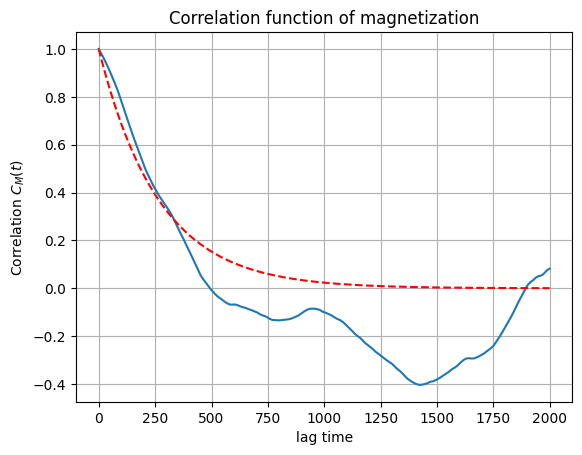

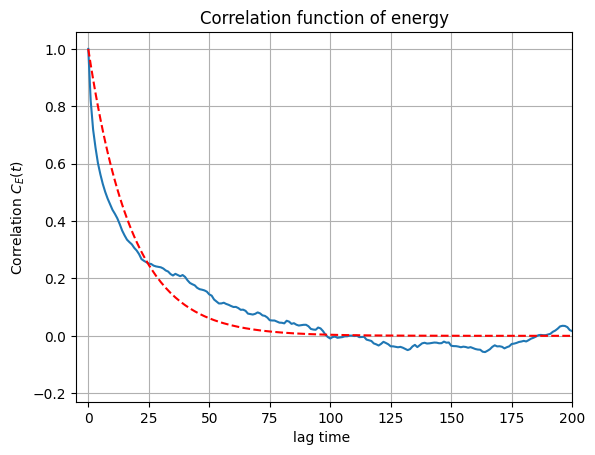

fit correlation time for energy  17.8972985762827
fit correlation time for magnetization  266.75025238750305
magnetization correlation time   228.89987238744192
energy correlation time    18.9631018917519


In [65]:
# Calculation Correlation function
C_M7 = corr_function_long(magnetization7a)
C_E7 = corr_function_long(energy7a)

C_m_norm7 = np.array([x1 / C_M7[0] for x1 in C_M7])
C_e_norm7 = np.array([y1 / C_E7[0] for y1 in C_E7])


def exp_decay(t, a):
    return np.exp(-t / a)

t = np.arange(len(C_e_norm7))

fit_set_e7 = (t >= 0) & (t <= 125)    # Energy correlation function fit
x_fit_e7 = t[fit_set_e7]
C_e_fit7 = C_e_norm7[fit_set_e7]
popt, pcov = curve_fit(exp_decay, x_fit_e7, C_e_fit7)  
a_fit_e7 = popt[0]  
exp_E7 = exp_decay(t, a_fit_e7)

fit_set_m7 = (t >= 0) & (t <= 500)    # Magnetization correlation function fit
x_fit_m7 = t[fit_set_m7]
C_m_fit7 = C_m_norm7[fit_set_m7]
popt, pcov = curve_fit(exp_decay, x_fit_m7, C_m_fit7)  
a_fit_m7 = popt[0]  
exp_M7 = exp_decay(t, a_fit_m7)

# Grafico della funzione di correlazione
plt.plot(C_m_norm7)
plt.plot(t, exp_M7, color='red', linestyle='--')
plt.xlabel("lag time")
plt.ylabel("Correlation $C_M(t)$")
#plt.axvline(x=80, color='red', linestyle='--')
plt.title("Correlation function of magnetization")
#plt.yscale('log')
#plt.xlim(-10,200)
plt.grid()
plt.show()

plt.plot(C_e_norm7)
plt.plot(t, exp_E7, color='red', linestyle='--')
plt.xlabel("lag time ")
plt.ylabel("Correlation $C_E(t)$")
plt.title("Correlation function of energy")
plt.xlim(-5,200)
plt.grid()
plt.show()

print('fit correlation time for energy ', a_fit_e7)
print('fit correlation time for magnetization ', a_fit_m7)

s = 0
for i in range(500):
    s += C_m_norm7[i]

print('magnetization correlation time  ',s)

l = 0
for i in range(75):
    l += C_e_norm7[i]

print('energy correlation time   ',l)

NEW ERRORS FOR MAGNETIZATION AND ENERGY

In [87]:
tcorr_e7 = 18.5 # Estimate of correlation time for the magnetization 
tcorr_m7 = 229 # Estimate of correlation time  for the energy

NewErrors(tcorr_m7, tcorr_e7, magnetization7a, energy7a, L_big)

new error bars for the magnetization   0.060843468616951286
new error bars for the energy   0.003502679167393667


----------------------------------------------------------------------------------- $T = 1.2 T_c$ -------------------------------------------------------------------------------------------

SIMULATION

In [13]:
time_big = 4000
L_big = 75
lattice8 = np.random.choice([-1,1], size=(L_big,L_big)) 
lattice8, magnetization8, energy8 = Ising(lattice8, 1.2*Tc, L_big, time_big)

SAVING AND LOADING DATA

In [47]:
save_data(lattice8, magnetization8, energy8, "lattice_T12_L75.npy", "M_T12_L75.npy","E_T12_L75.npy")

Dati salvati:
- lattice_T12_L75.npy
- M_T12_L75.npy
- E_T12_L75.npy


In [49]:
lattice8_a, magnetization8_a, energy8_a = load_data("lattice_T12_L75.npy", "M_T12_L75.npy","E_T12_L75.npy")

Dati caricati:
- lattice_T12_L75.npy
- M_T12_L75.npy
- E_T12_L75.npy


PLOT ENERGY AND MAGNETIZATION + LATTICE AT THE END 

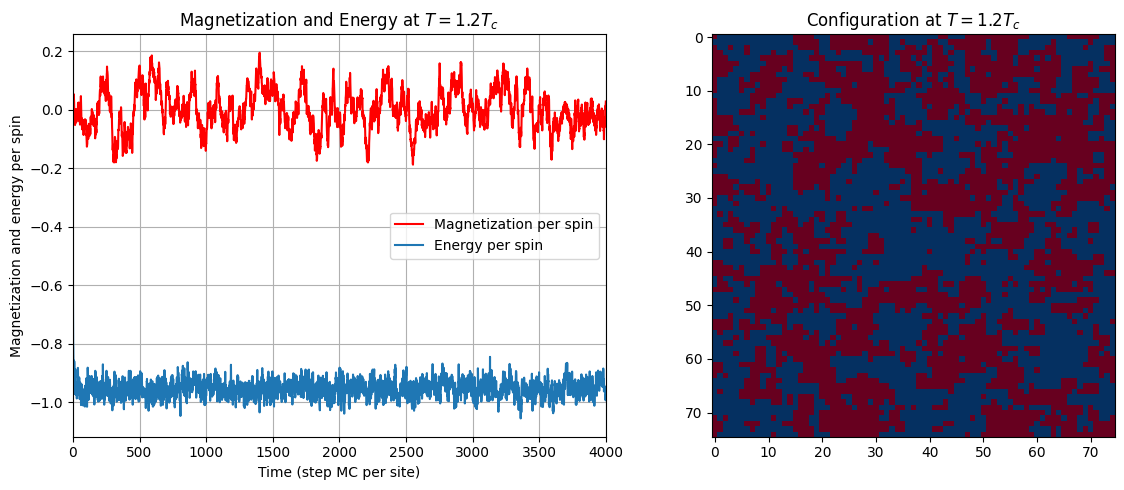

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].plot(magnetization8, color='r',label = 'Magnetization per spin' )
ax[0].plot(energy8, label = 'Energy per spin')
ax[0].set_title("Magnetization and Energy at $T = 1.2 T_c$")
ax[0].set_xlabel("Time (step MC per site)")
ax[0].set_ylabel("Magnetization and energy per spin")
ax[0].set_xlim(0, 4000)
ax[0].grid(True)
ax[0].legend()

ax[1].imshow(lattice8, cmap='RdBu')
ax[1].set_title("Configuration at $T = 1.2 T_c$")
plt.tight_layout()
plt.show()

FROM THE FILES, USE DATA

In [50]:
magnetization8a = magnetization8_a  
energy8a = energy8_a

AVERAGES

In [53]:
M8, sigma_M8, chi_M8, E8, sigma_E8, C_V8 = Averages(1.2*Tc, L_big, magnetization8a, energy8a) 
print('Average of the magnetization  ' f"{M8}1 \u00B1 {sigma_M8}")
print('Average of the energy  ' f"{E8} \u00B1 {sigma_E8}")
print('Magnetic susceptibility  ', chi_M8)
print('Specific heat   ', C_V8)
fin_chi752, fin_C752, sigma_chi752, sigma_C752 = Fluctuations(1.2*Tc, L_big, magnetization8a, energy8a, 20)
print('Final susceptiblity (blocks)  ' f"{fin_chi752}1 \u00B1 {sigma_chi752}")
print('Final specific heat (blocks)  ' f"{fin_C752} \u00B1 {sigma_C752}")

Average of the magnetization  0.00070844444444444591 ± 0.0010612096774232696
Average of the energy  -0.9524426666666692 ± 0.00046262215091602164
Magnetic susceptibility   9.305371395873907
Specific heat    0.00011545438115342093
Final susceptiblity (blocks)  7.7973337043158961 ± 0.9425125189460104
Final specific heat (blocks)  0.00011052607938220397 ± 9.193490150552973e-06


CORRELATION FUNCTIONS + ESTIMATION OF CORRELATION TIME

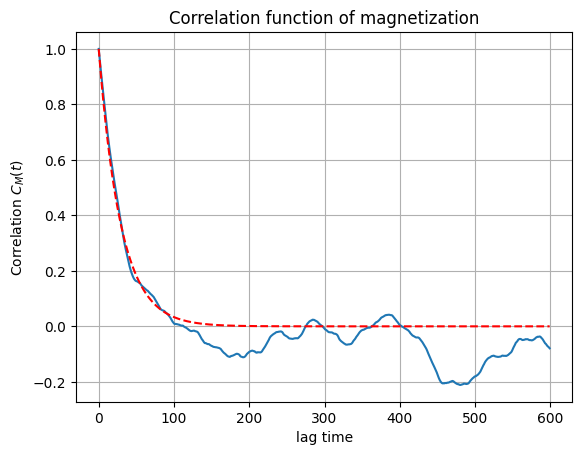

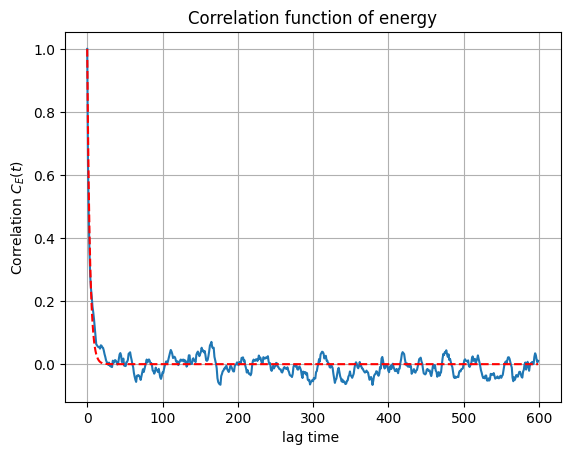

fit correlation time for energy  3.463622298270005
fit correlation time for magnetization  29.375473591975066
magnetization correlation time   29.43628433428867
energy correlation time    4.56070674438183


In [91]:
# Calculation Correlation function
C_M8 = corr_function(magnetization8a)
C_E8 = corr_function(energy8a)

C_m_norm8 = np.array([x1 / C_M8[0] for x1 in C_M8])
C_e_norm8 = np.array([y1 / C_E8[0] for y1 in C_E8])


def exp_decay(t, a):
    return np.exp(-t / a)

t = np.arange(len(C_e_norm8))

fit_set_e8 = (t >= 0) & (t <= 50)    # Energy correlation function fit
x_fit_e8 = t[fit_set_e8]
C_e_fit8 = C_e_norm8[fit_set_e8]
popt, pcov = curve_fit(exp_decay, x_fit_e8, C_e_fit8)  
a_fit_e8 = popt[0]  
exp_E8 = exp_decay(t, a_fit_e8)

fit_set_m8 = (t >= 0) & (t <= 150)    # Magnetization correlation function fit
x_fit_m8 = t[fit_set_m8]
C_m_fit8 = C_m_norm8[fit_set_m8]
popt, pcov = curve_fit(exp_decay, x_fit_m8, C_m_fit8)  
a_fit_m8 = popt[0]  
exp_M8 = exp_decay(t, a_fit_m8)

# Grafico della funzione di correlazione
plt.plot(C_m_norm8)
plt.plot(t, exp_M8, color='red', linestyle='--')
plt.xlabel("lag time")
plt.ylabel("Correlation $C_M(t)$")
#plt.axvline(x=80, color='red', linestyle='--')
plt.title("Correlation function of magnetization")
#plt.yscale('log')
#plt.xlim(-10,200)
plt.grid()
plt.show()

plt.plot(C_e_norm8)
plt.plot(t, exp_E8, color='red', linestyle='--')
plt.xlabel("lag time ")
plt.ylabel("Correlation $C_E(t)$")
plt.title("Correlation function of energy")
#plt.xlim(-5,200)
plt.grid()
plt.show()

print('fit correlation time for energy ', a_fit_e8)
print('fit correlation time for magnetization ', a_fit_m8)

s = 0
for i in range(120):
    s += C_m_norm8[i]

print('magnetization correlation time  ',s)

l = 0
for i in range(35):
    l += C_e_norm8[i]

print('energy correlation time   ',l)

NEW ERROR BARS FOR MAGNETIZATION AND ENERGY

In [92]:
tcorr_e8 = 4.6 # second method more precise
tcorr_m8 = 29.4
NewErrors(tcorr_m8, tcorr_e8, magnetization8a, energy8a, L_big)

new error bars for the magnetization   0.008206383221097869
new error bars for the energy   0.0014774966653381305
